# UNSW-NB15 : CNN-BiLSTM Multiclass Intrusion Detection
**Pipeline:** Preprocessing -> PyTorch DataLoaders -> CNN-BiLSTM -> 5-Fold CV -> Evaluation

## 1. Configuration

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
DATA_PATH        = '/content/drive/MyDrive/Tez_kodu/UNSW-NB15'
MISSING_STRATEGY = 'mean'
SCALING          = 'quantile'
SPLIT            = 'stratified'
OVERSAMPLING     = 'smote'
TASK             = 'multiclass'
ENCODING         = 'onehot'
LOSS_CHOICE      = 'focal'
TEST_SIZE        = 0.2
RANDOM_STATE     = 42

#  CNN-BiLSTM Hyperparameters
BATCH_SIZE   = 256
EPOCHS       = 100
LR           = 1e-3
N_FOLDS      = 5
PATIENCE     = 7        # early stopping patience

# CNN
CNN_OUT_CHANNELS = [64, 128]   # filters per conv layer
CNN_KERNEL_SIZE  = 3
CNN_DROPOUT      = 0.3

# BiLSTM
LSTM_HIDDEN  = 128
LSTM_LAYERS  = 2
LSTM_DROPOUT = 0.3

# Classifier head
FC_HIDDEN    = 128
FC_DROPOUT   = 0.3

print(' Configuration loaded')
print(f'  Task: {TASK} | Scaling: {SCALING} | Oversampling: {OVERSAMPLING}')
print(f'  Batch: {BATCH_SIZE} | Epochs: {EPOCHS} | Folds: {N_FOLDS} | Patience: {PATIENCE}')

 Configuration loaded
  Task: multiclass | Scaling: quantile | Oversampling: smote
  Batch: 256 | Epochs: 100 | Folds: 5 | Patience: 7


## 2. Imports

In [ ]:
import os, glob, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

# Sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, QuantileTransformer,
    LabelEncoder, OneHotEncoder, TargetEncoder
)
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, f1_score, accuracy_score,
    precision_score, recall_score,
    precision_recall_curve, roc_curve, auc
)

# Imbalanced-learn
from imblearn.over_sampling import SMOTE, BorderlineSMOTE, ADASYN, RandomOverSampler
from imblearn.combine import SMOTETomek

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset

# Reproducibility
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f' Imports OK  |  Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'  GPU: {torch.cuda.get_device_name(0)}')

 Imports OK  |  Device: cuda
  GPU: Tesla T4


## 3. Data Loading

In [ ]:
if os.path.isdir(DATA_PATH):
    csv_files = glob.glob(os.path.join(DATA_PATH, '*.csv'))
    print(f'{len(csv_files)} CSV files found:')
    for f in csv_files:
        print(f'   {os.path.basename(f)}')
    df = pd.concat([pd.read_csv(f, low_memory=False) for f in csv_files], ignore_index=True)
else:
    df = pd.read_csv(DATA_PATH, low_memory=False)

df.columns = df.columns.str.strip().str.lower()
print(f'\nShape: {df.shape}')
print(f'Columns sample: {list(df.columns[:8])}')

2 CSV files found:
   UNSW_NB15_training-set.csv
   UNSW_NB15_testing-set.csv

Shape: (257673, 45)
Columns sample: ['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes']


## 4. Cleaning & Encoding

In [ ]:
# 4.1 Infinite -> NaN
inf_count = np.isinf(df.select_dtypes(include=np.number)).sum().sum()
df.replace([np.inf, -np.inf], np.nan, inplace=True)
print(f'{inf_count:,} infinite values replaced by NaN')

# 4.2 Missing values
if MISSING_STRATEGY == 'drop':
    df.dropna(inplace=True)
else:
    num_cols = df.select_dtypes(include=np.number).columns
    df[num_cols] = df[num_cols].fillna(df[num_cols].mean())
print(f'Missing after: {df.isnull().sum().sum()}')

# 4.3 Target encoding (multiclass)
le = None
if TASK == 'multiclass':
    df['attack_cat'] = (df['attack_cat'].astype(str)
                        .str.strip()
                        .replace({'nan': 'Normal', '': 'Normal'}))
    le = LabelEncoder()
    df['Label_encoded'] = le.fit_transform(df['attack_cat'])
    print('Label mapping:')
    for i, cls in enumerate(le.classes_):
        print(f'  {i:2d} : {cls}')
else:
    df['Label_encoded'] = df['label'].astype(int)

# 4.4 Categorical features (OneHot)
EXCLUDE = ['label', 'attack_cat', 'Label_encoded'] # Changed 'label_encoded' to 'Label_encoded'
cat_cols = [c for c in df.select_dtypes(include='object').columns if c not in EXCLUDE]

if cat_cols and ENCODING == 'onehot':
    df = pd.get_dummies(df, columns=cat_cols, drop_first=False)
    print(f'OneHot encoding applied on: {cat_cols}')

# 4.5 Feature matrix
FEATURE_COLS = [c for c in df.select_dtypes(include=np.number).columns if c not in EXCLUDE]
X = df[FEATURE_COLS].copy().astype(np.float32)
y = df['Label_encoded'].values.astype(np.int64) # Changed 'label_encoded' to 'Label_encoded'

N_FEATURES = X.shape[1]
N_CLASSES  = len(np.unique(y))
CLASS_NAMES = [str(c) for c in le.classes_] if le is not None else ['BENIGN', 'ATTACK']

print(f'\nFeatures : {N_FEATURES} | Samples: {X.shape[0]:,} | Classes: {N_CLASSES}')

0 infinite values replaced by NaN
Missing after: 0
Label mapping:
   0 : Analysis
   1 : Backdoor
   2 : DoS
   3 : Exploits
   4 : Fuzzers
   5 : Generic
   6 : Normal
   7 : Reconnaissance
   8 : Shellcode
   9 : Worms
OneHot encoding applied on: ['proto', 'service', 'state']

Features : 40 | Samples: 257,673 | Classes: 10


## 5. Train / Validation / Test Split

In [ ]:
stratify_param = y if SPLIT == 'stratified' else None

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=stratify_param
)
stratify_temp = y_temp if SPLIT == 'stratified' else None
X_test, X_val, y_test, y_val = train_test_split(
    X_temp, y_temp, test_size=0.333, random_state=RANDOM_STATE, stratify=stratify_temp
)

print(f'Split ({SPLIT})')
print(f'  Train      : {X_train.shape[0]:,} (70%)')
print(f'  Validation : {X_val.shape[0]:,} (10%)')
print(f'  Test       : {X_test.shape[0]:,} (20%)')

Split (stratified)
  Train      : 180,371 (70%)
  Validation : 25,742 (10%)
  Test       : 51,560 (20%)


## 6. Scaling

In [ ]:
if SCALING is None:
    X_train_scaled = X_train.values.astype(np.float32)
    X_val_scaled   = X_val.values.astype(np.float32)
    X_test_scaled  = X_test.values.astype(np.float32)
    print('No scaling applied')
else:
    scalers = {
        'standard': StandardScaler(),
        'minmax'  : MinMaxScaler(),
        'quantile': QuantileTransformer(output_distribution='normal', random_state=RANDOM_STATE)
    }
    scaler = scalers[SCALING]
    # IMPORTANT: fit on train only
    X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)
    X_val_scaled   = scaler.transform(X_val).astype(np.float32)
    X_test_scaled  = scaler.transform(X_test).astype(np.float32)
    print(f' Scaling [{SCALING}] applied — fit on train only')

 Scaling [quantile] applied — fit on train only


## 7. Oversampling (train only)

In [ ]:
y_train_arr = y_train if isinstance(y_train, np.ndarray) else np.array(y_train)
print(f'Before oversampling: {dict(zip(*np.unique(y_train_arr, return_counts=True)))}')

if OVERSAMPLING is None:
    X_train_res, y_train_res = X_train_scaled, y_train_arr
    print('No oversampling')
else:
    oversamplers = {
        'smote'           : SMOTE(random_state=RANDOM_STATE),
        'borderline_smote': BorderlineSMOTE(random_state=RANDOM_STATE),
        'adasyn'          : ADASYN(random_state=RANDOM_STATE),
        'smote_tomek'     : SMOTETomek(random_state=RANDOM_STATE),
        'random'          : RandomOverSampler(random_state=RANDOM_STATE)
    }
    sampler = oversamplers[OVERSAMPLING]
    X_train_res, y_train_res = sampler.fit_resample(X_train_scaled, y_train_arr)
    X_train_res = X_train_res.astype(np.float32)
    y_train_res = y_train_res.astype(np.int64)
    print(f' {OVERSAMPLING} applied')

print(f'After  oversampling: {dict(zip(*np.unique(y_train_res, return_counts=True)))}')
print(f'Train size after   : {X_train_res.shape[0]:,}')

Before oversampling: {np.int64(0): np.int64(1874), np.int64(1): np.int64(1630), np.int64(2): np.int64(11447), np.int64(3): np.int64(31167), np.int64(4): np.int64(16972), np.int64(5): np.int64(41210), np.int64(6): np.int64(65100), np.int64(7): np.int64(9791), np.int64(8): np.int64(1058), np.int64(9): np.int64(122)}
 smote applied
After  oversampling: {np.int64(0): np.int64(65100), np.int64(1): np.int64(65100), np.int64(2): np.int64(65100), np.int64(3): np.int64(65100), np.int64(4): np.int64(65100), np.int64(5): np.int64(65100), np.int64(6): np.int64(65100), np.int64(7): np.int64(65100), np.int64(8): np.int64(65100), np.int64(9): np.int64(65100)}
Train size after   : 651,000


## 8. PyTorch Dataset & DataLoaders

In [ ]:
class IDSDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        # X: (N, F)  ->  (N, 1, F)  [channels=1 for CNN]
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(1)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


def make_loader(X, y, batch_size, shuffle=True):
    ds = IDSDataset(X, y)
    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=True,          # required
        num_workers=0,
        pin_memory=(DEVICE.type == 'cuda')
    )


# Full-data loaders (used outside CV for final test evaluation)
train_loader = make_loader(X_train_res, y_train_res, BATCH_SIZE, shuffle=True)
val_loader   = make_loader(X_val_scaled, y_val,       BATCH_SIZE, shuffle=False)
test_loader  = make_loader(X_test_scaled, y_test,     BATCH_SIZE, shuffle=False)

print(f' DataLoaders created  (drop_last=True)')
print(f'  Train batches : {len(train_loader)}')
print(f'  Val   batches : {len(val_loader)}')
print(f'  Test  batches : {len(test_loader)}')

# Sanity check
xb, yb = next(iter(train_loader))
print(f'  Batch shape   : X={tuple(xb.shape)}  y={tuple(yb.shape)}')

 DataLoaders created  (drop_last=True)
  Train batches : 2542
  Val   batches : 100
  Test  batches : 201
  Batch shape   : X=(256, 1, 40)  y=(256,)


## 9. CNN-BiLSTM Architecture

In [ ]:
class CNNBiLSTM(nn.Module):
    """
    CNN-BiLSTM for multiclass intrusion detection.
    """
    def __init__(self, n_features, n_classes,
                 cnn_channels=None, cnn_kernel=3, cnn_dropout=0.3,
                 lstm_hidden=128, lstm_layers=2, lstm_dropout=0.3,
                 fc_hidden=128, fc_dropout=0.3):
        super().__init__()
        if cnn_channels is None:
            cnn_channels = [64, 128]

        #  CNN blocks
        cnn_layers = []
        in_ch = 1
        for out_ch in cnn_channels:
            cnn_layers += [
                nn.Conv1d(in_ch, out_ch, kernel_size=cnn_kernel,
                          padding=cnn_kernel // 2),
                nn.BatchNorm1d(out_ch),
                nn.ReLU(inplace=True),
                nn.Dropout(cnn_dropout)
            ]
            in_ch = out_ch
        self.cnn = nn.Sequential(*cnn_layers)
        cnn_out_ch = cnn_channels[-1]   # 128

        #  BiLSTM
        self.bilstm = nn.LSTM(
            input_size=cnn_out_ch,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=True,
            dropout=lstm_dropout if lstm_layers > 1 else 0.0
        )

        lstm_out_dim = lstm_hidden * 2  # bidirectional → ×2

        #  Classifier head
        self.classifier = nn.Sequential(
            nn.Linear(lstm_out_dim, fc_hidden),
            nn.BatchNorm1d(fc_hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(fc_dropout),
            nn.Linear(fc_hidden, n_classes)
        )

    def forward(self, x):
        # x: (B, 1, F)
        x = self.cnn(x)              # (B, 128, F)
        x = x.permute(0, 2, 1)      # (B, F, 128) — seq_len=F, features=128
        x, _ = self.bilstm(x)       # (B, F, 256)
        x = x[:, -1, :]             # last timestep → (B, 256)
        x = self.classifier(x)      # (B, N_CLASSES)
        return x


def build_model():
    return CNNBiLSTM(
        n_features   = N_FEATURES,
        n_classes    = N_CLASSES,
        cnn_channels = CNN_OUT_CHANNELS,
        cnn_kernel   = CNN_KERNEL_SIZE,
        cnn_dropout  = CNN_DROPOUT,
        lstm_hidden  = LSTM_HIDDEN,
        lstm_layers  = LSTM_LAYERS,
        lstm_dropout = LSTM_DROPOUT,
        fc_hidden    = FC_HIDDEN,
        fc_dropout   = FC_DROPOUT
    ).to(DEVICE)


# Quick architecture summary
model = build_model()
total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'\nTotal params    : {total_params:,}')
print(f'Trainable params: {trainable:,}')
del model

CNNBiLSTM(
  (cnn): Sequential(
    (0): Conv1d(1, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): Dropout(p=0.3, inplace=False)
  )
  (bilstm): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (classifier): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)

Total params    : 719,242
Trainable params: 719,242


## 10. Loss Function (Focal Loss)

In [ ]:
class FocalLoss(nn.Module):
    """
    Multi-class Focal Loss.
    FL(p_t) = -alpha * (1 - p_t)^gamma * log(p_t)
    """
    def __init__(self, gamma=2.0, alpha=None, reduction='mean'):
        super().__init__()
        self.gamma     = gamma
        self.alpha     = alpha  # tensor of shape (n_classes,) or None
        self.reduction = reduction

    def forward(self, inputs, targets):
        # inputs : (B, C) raw logits
        # targets: (B,)   class indices
        log_probs = F.log_softmax(inputs, dim=1)          # (B, C)
        probs     = torch.exp(log_probs)                  # (B, C)
        # Gather the prob of the true class for each sample
        log_pt = log_probs.gather(1, targets.view(-1, 1)).squeeze(1)  # (B,)
        pt     = probs.gather(1, targets.view(-1, 1)).squeeze(1)      # (B,)
        focal  = -((1 - pt) ** self.gamma) * log_pt                   # (B,)
        if self.alpha is not None:
            alpha_t = self.alpha.to(inputs.device)[targets]
            focal   = alpha_t * focal
        return focal.mean() if self.reduction == 'mean' else focal.sum()


def get_loss_fn(choice, y_train_labels):
    if choice == 'focal':
        return FocalLoss(gamma=2.0)
    elif choice == 'weighted_ce':
        counts  = np.bincount(y_train_labels)
        weights = 1.0 / (counts + 1e-6)
        weights = weights / weights.sum() * len(counts)
        return nn.CrossEntropyLoss(weight=torch.tensor(weights, dtype=torch.float32).to(DEVICE))
    else:  # 'ce'
        return nn.CrossEntropyLoss()


print(f' Loss function: {LOSS_CHOICE}')

 Loss function: focal


## 11. Training & Evaluation Functions

In [ ]:

# One epoch: train
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss   = criterion(logits, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * X_batch.size(0)
        preds       = logits.argmax(dim=1)
        correct    += (preds == y_batch).sum().item()
        total      += X_batch.size(0)
    return total_loss / total, correct / total



# One epoch: evaluate
@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_targets, all_probs = [], [], []
    t0 = time.perf_counter()

    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        logits = model(X_batch)
        loss   = criterion(logits, y_batch)
        probs  = F.softmax(logits, dim=1)
        preds  = logits.argmax(dim=1)
        total_loss += loss.item() * X_batch.size(0)
        correct    += (preds == y_batch).sum().item()
        total      += X_batch.size(0)
        all_preds.append(preds.cpu().numpy())
        all_targets.append(y_batch.cpu().numpy())
        all_probs.append(probs.cpu().numpy())

    elapsed = time.perf_counter() - t0
    all_preds   = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)
    all_probs   = np.concatenate(all_probs)
    return {
        'loss'    : total_loss / total,
        'acc'     : correct / total,
        'preds'   : all_preds,
        'targets' : all_targets,
        'probs'   : all_probs,
        'time_s'  : elapsed,
        'n_samples': total
    }



# Full training loop with early stopping
def train_model(model, train_loader, val_loader,
                criterion, optimizer, epochs, patience,
                verbose=True, fold_id=None):
    """
    Trains model with early stopping on val loss.
    Returns history dict and best model state.
    """
    history = {'train_loss': [], 'val_loss': [],
               'train_acc' : [], 'val_acc' : []}
    best_val_loss = float('inf')
    best_state    = None
    no_improve    = 0
    prefix        = f'[Fold {fold_id}] ' if fold_id is not None else ''

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        val_res         = evaluate(model, val_loader, criterion)
        val_loss        = val_res['loss']
        val_acc         = val_res['acc']

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state    = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve    = 0
        else:
            no_improve += 1

        if verbose and (epoch % 5 == 0 or epoch == 1):
            print(f'{prefix}Epoch {epoch:3d}/{epochs} '
                  f'| tr_loss={tr_loss:.4f} tr_acc={tr_acc:.4f} '
                  f'| val_loss={val_loss:.4f} val_acc={val_acc:.4f} '
                  f'| patience={no_improve}/{patience}')

        if no_improve >= patience:
            if verbose:
                print(f'{prefix}Early stopping at epoch {epoch} '
                      f'(best val_loss={best_val_loss:.4f})')
            break

    model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})
    return history, best_val_loss


print(' Training functions defined')

 Training functions defined


## 12. 5-Fold Cross-Validation

In [ ]:
# We run CV on the combined (train + val) scaled data
# Oversampling is applied per-fold on the fold's train split only
X_cv = np.vstack([X_train_scaled, X_val_scaled]).astype(np.float32)
y_cv = np.concatenate([y_train if isinstance(y_train, np.ndarray) else np.array(y_train),
                        y_val   if isinstance(y_val,   np.ndarray) else np.array(y_val)])
y_cv = y_cv.astype(np.int64)

skf          = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
cv_histories = []
cv_results   = []   # per-fold metrics
fold_best_states = []

print(f' Starting {N_FOLDS}-Fold Cross-Validation')
print(f'  CV pool size: {X_cv.shape[0]:,}  |  Classes: {N_CLASSES}')
print('=' * 65)

for fold, (tr_idx, vl_idx) in enumerate(skf.split(X_cv, y_cv), start=1):
    print(f'\n FOLD {fold}/{N_FOLDS}')

    X_tr_fold, y_tr_fold = X_cv[tr_idx], y_cv[tr_idx]
    X_vl_fold, y_vl_fold = X_cv[vl_idx], y_cv[vl_idx]

    # Per-fold oversampling on train split only
    if OVERSAMPLING is not None:
        sampler = SMOTE(random_state=RANDOM_STATE)
        X_tr_fold, y_tr_fold = sampler.fit_resample(X_tr_fold, y_tr_fold)
        X_tr_fold = X_tr_fold.astype(np.float32)
        y_tr_fold = y_tr_fold.astype(np.int64)

    fold_train_loader = make_loader(X_tr_fold, y_tr_fold, BATCH_SIZE, shuffle=True)
    fold_val_loader   = make_loader(X_vl_fold, y_vl_fold, BATCH_SIZE, shuffle=False)

    model     = build_model()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    criterion = get_loss_fn(LOSS_CHOICE, y_tr_fold)

    history, best_val_loss = train_model(
        model, fold_train_loader, fold_val_loader,
        criterion, optimizer,
        epochs=EPOCHS, patience=PATIENCE,
        verbose=True, fold_id=fold
    )

    # Evaluate this fold
    res = evaluate(model, fold_val_loader, criterion)
    preds, targets, probs = res['preds'], res['targets'], res['probs']

    acc  = accuracy_score(targets, preds)
    prec = precision_score(targets, preds, average='macro', zero_division=0)
    rec  = recall_score(targets, preds,    average='macro', zero_division=0)
    f1   = f1_score(targets, preds,        average='macro', zero_division=0)

    # FPR (macro average: FP / (FP + TN) per class)
    cm   = confusion_matrix(targets, preds, labels=list(range(N_CLASSES)))
    fprs = []
    for c in range(N_CLASSES):
        fp = cm[:, c].sum() - cm[c, c]
        tn = cm.sum() - cm[c, :].sum() - cm[:, c].sum() + cm[c, c]
        fprs.append(fp / (fp + tn + 1e-8))
    fpr_macro = np.mean(fprs)

    # ROC-AUC (OvR macro)
    try:
        roc_auc = roc_auc_score(targets, probs, multi_class='ovr', average='macro')
    except ValueError:
        roc_auc = float('nan')

    det_time_ms = (res['time_s'] / res['n_samples']) * 1000
    throughput  = res['n_samples'] / res['time_s']

    cv_results.append({
        'fold': fold, 'acc': acc, 'precision': prec,
        'recall': rec, 'f1': f1, 'fpr': fpr_macro,
        'roc_auc': roc_auc, 'det_time_ms': det_time_ms,
        'throughput': throughput
    })
    cv_histories.append(history)
    fold_best_states.append({k: v.clone() for k, v in model.state_dict().items()})

    print(f'  Fold {fold} → Acc={acc:.4f} F1={f1:.4f} '
          f'Prec={prec:.4f} Rec={rec:.4f} '
          f'FPR={fpr_macro:.4f} AUC={roc_auc:.4f}')

print('\n' + '=' * 65)
print(' Cross-Validation complete')

 Starting 5-Fold Cross-Validation
  CV pool size: 206,113  |  Classes: 10

 FOLD 1/5
[Fold 1] Epoch   1/100 | tr_loss=0.6523 tr_acc=0.5932 | val_loss=0.4308 val_acc=0.7150 | patience=0/7
[Fold 1] Epoch   5/100 | tr_loss=0.4109 tr_acc=0.7004 | val_loss=0.3487 val_acc=0.7422 | patience=0/7
[Fold 1] Epoch  10/100 | tr_loss=0.3631 tr_acc=0.7259 | val_loss=0.3313 val_acc=0.7383 | patience=2/7
[Fold 1] Epoch  15/100 | tr_loss=0.3427 tr_acc=0.7387 | val_loss=0.3269 val_acc=0.7716 | patience=2/7
[Fold 1] Epoch  20/100 | tr_loss=0.3288 tr_acc=0.7486 | val_loss=0.3284 val_acc=0.7582 | patience=7/7
[Fold 1] Early stopping at epoch 20 (best val_loss=0.3229)
  Fold 1 → Acc=0.7582 F1=0.5112 Prec=0.5094 Rec=0.6381 FPR=0.0261 AUC=0.9617

 FOLD 2/5
[Fold 2] Epoch   1/100 | tr_loss=0.6449 tr_acc=0.5997 | val_loss=0.4015 val_acc=0.7007 | patience=0/7
[Fold 2] Epoch   5/100 | tr_loss=0.4127 tr_acc=0.6990 | val_loss=0.3394 val_acc=0.7681 | patience=0/7
[Fold 2] Epoch  10/100 | tr_loss=0.3675 tr_acc=0.7239 

## 13. CV Summary (mean ± std)

In [ ]:
cv_df = pd.DataFrame(cv_results).set_index('fold')
display(cv_df.round(4))

metrics = ['acc', 'precision', 'recall', 'f1', 'fpr', 'roc_auc', 'det_time_ms', 'throughput']
print('\n Cross-Validation Summary (mean ± std)')
print('-' * 50)
for m in metrics:
    vals = cv_df[m].values
    print(f'  {m:<15} {vals.mean():.4f} ± {vals.std():.4f}')

,acc,precision,recall,f1,fpr,roc_auc,det_time_ms,throughput
fold,,,,,,,,
1,0.7582,0.5094,0.6381,0.5112,0.0261,0.9617,0.0488,20492.2839
2,0.7683,0.5101,0.6226,0.5178,0.0251,0.9628,0.0447,22368.1747
3,0.7649,0.5097,0.6234,0.5168,0.0253,0.9610,0.0443,22590.3756
4,0.7671,0.5116,0.6266,0.5133,0.0253,0.9601,0.0446,22429.1370
5,0.7615,0.5154,0.6498,0.5116,0.0258,0.9599,0.0445,22465.9349



 Cross-Validation Summary (mean ± std)
--------------------------------------------------
  acc             0.7640 ± 0.0037
  precision       0.5112 ± 0.0022
  recall          0.6321 ± 0.0104
  f1              0.5141 ± 0.0027
  fpr             0.0256 ± 0.0004
  roc_auc         0.9611 ± 0.0011
  det_time_ms     0.0454 ± 0.0017
  throughput      22069.1812 ± 791.7863


## 14. Final Evaluation on Test Set

In [ ]:
# Use the best fold model (highest F1) for final test evaluation
best_fold_idx = cv_df['f1'].values.argmax()
print(f' Using fold {best_fold_idx + 1} (best F1={cv_df["f1"].iloc[best_fold_idx]:.4f})')

best_model = build_model()
best_model.load_state_dict({k: v.to(DEVICE) for k, v in fold_best_states[best_fold_idx].items()})

criterion_test = get_loss_fn(LOSS_CHOICE, y_train_res)
test_res = evaluate(best_model, test_loader, criterion_test)

y_pred  = test_res['preds']
y_true  = test_res['targets']
y_probs = test_res['probs']

acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
rec  = recall_score(y_true, y_pred,    average='macro', zero_division=0)
f1   = f1_score(y_true, y_pred,        average='macro', zero_division=0)

cm   = confusion_matrix(y_true, y_pred, labels=list(range(N_CLASSES)))
fprs_per_class = []
for c in range(N_CLASSES):
    fp = cm[:, c].sum() - cm[c, c]
    tn = cm.sum() - cm[c, :].sum() - cm[:, c].sum() + cm[c, c]
    fprs_per_class.append(fp / (fp + tn + 1e-8))
fpr_macro = np.mean(fprs_per_class)

try:
    roc_auc = roc_auc_score(y_true, y_probs, multi_class='ovr', average='macro')
except ValueError:
    roc_auc = float('nan')

det_time_ms = (test_res['time_s'] / test_res['n_samples']) * 1000
throughput  = test_res['n_samples'] / test_res['time_s']

print('\n TEST SET RESULTS')
print('=' * 45)
print(f'  Accuracy        : {acc:.4f}')
print(f'  Precision (mac) : {prec:.4f}')
print(f'  Recall (macro)  : {rec:.4f}')
print(f'  F1-Score (mac)  : {f1:.4f}')
print(f'  FPR (macro)     : {fpr_macro:.4f}')
print(f'  ROC-AUC (OvR)   : {roc_auc:.4f}')
print(f'  Detection time  : {det_time_ms:.4f} ms/sample')
print(f'  Throughput      : {throughput:,.0f} samples/sec')
print('\n Per-class report:')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))

 Using fold 2 (best F1=0.5178)

 TEST SET RESULTS
  Accuracy        : 0.7643
  Precision (mac) : 0.5154
  Recall (macro)  : 0.6462
  F1-Score (mac)  : 0.5258
  FPR (macro)     : 0.0255
  ROC-AUC (OvR)   : 0.9637
  Detection time  : 0.0445 ms/sample
  Throughput      : 22,476 samples/sec

 Per-class report:
                precision    recall  f1-score   support

      Analysis       0.08      0.32      0.13       535
      Backdoor       0.08      0.48      0.14       466
           DoS       0.35      0.46      0.40      3261
      Exploits       0.85      0.48      0.62      8899
       Fuzzers       0.61      0.72      0.66      4844
       Generic       1.00      0.97      0.99     11762
        Normal       0.96      0.85      0.90     18564
Reconnaissance       0.82      0.80      0.81      2789
     Shellcode       0.29      0.80      0.42       301
         Worms       0.12      0.57      0.20        35

      accuracy                           0.76     51456
     macro avg    

## 15. Confusion Matrix

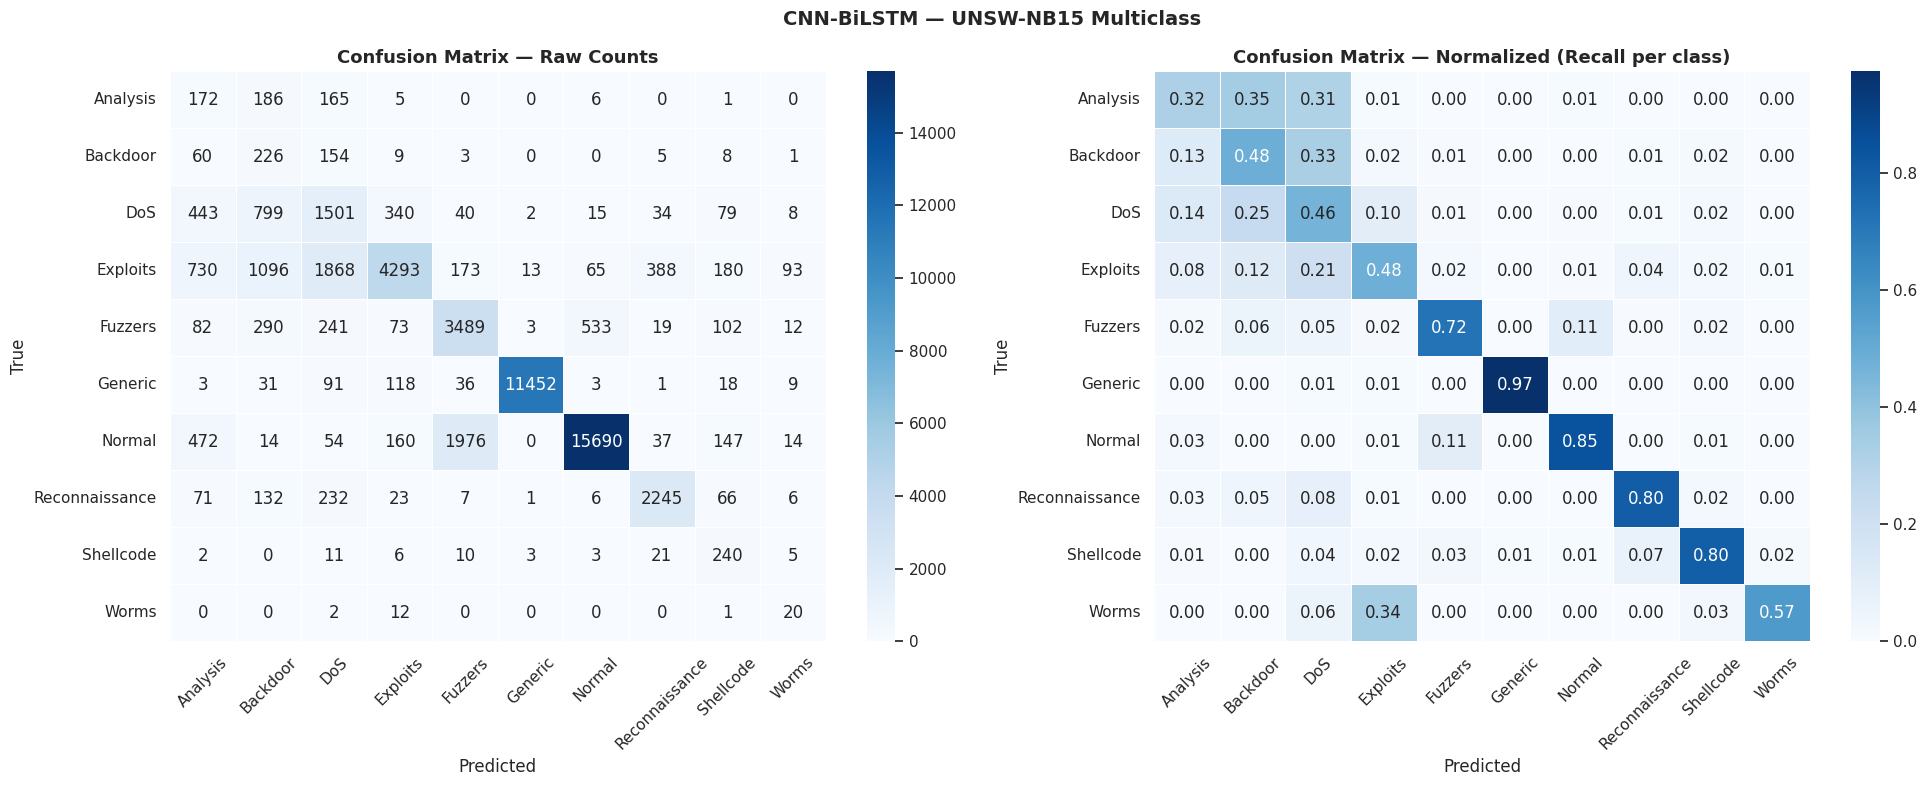

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Confusion Matrix — Raw Counts', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
axes[0].tick_params(axis='x', rotation=45)

# Normalized
cm_norm = cm.astype('float') / (cm.sum(axis=1, keepdims=True) + 1e-8)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Confusion Matrix — Normalized (Recall per class)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('CNN-BiLSTM — UNSW-NB15 Multiclass', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 16. Training Curves (CV Folds)

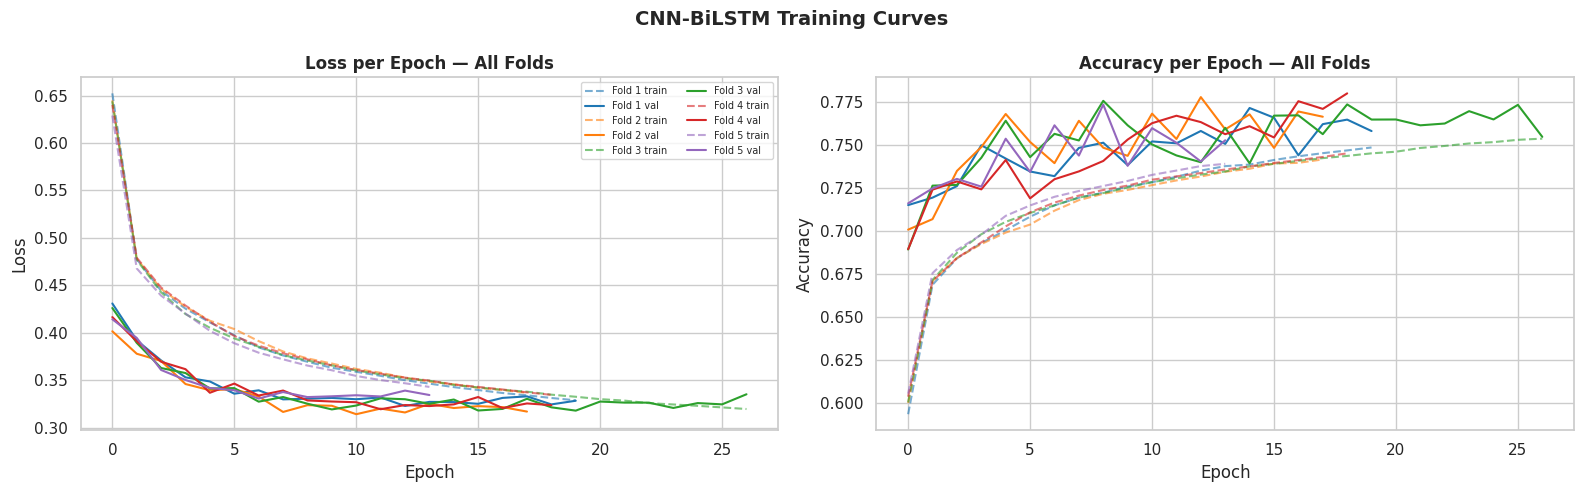

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
colors = plt.cm.tab10.colors

for i, hist in enumerate(cv_histories):
    c = colors[i]
    axes[0].plot(hist['train_loss'], color=c, alpha=0.6, linestyle='--', label=f'Fold {i+1} train')
    axes[0].plot(hist['val_loss'],   color=c, alpha=1.0, label=f'Fold {i+1} val')
    axes[1].plot(hist['train_acc'],  color=c, alpha=0.6, linestyle='--')
    axes[1].plot(hist['val_acc'],    color=c, alpha=1.0)

axes[0].set_title('Loss per Epoch — All Folds', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(fontsize=7, ncol=2)

axes[1].set_title('Accuracy per Epoch — All Folds', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')

plt.suptitle('CNN-BiLSTM Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 17. Per-Fold Metrics Bar Charts

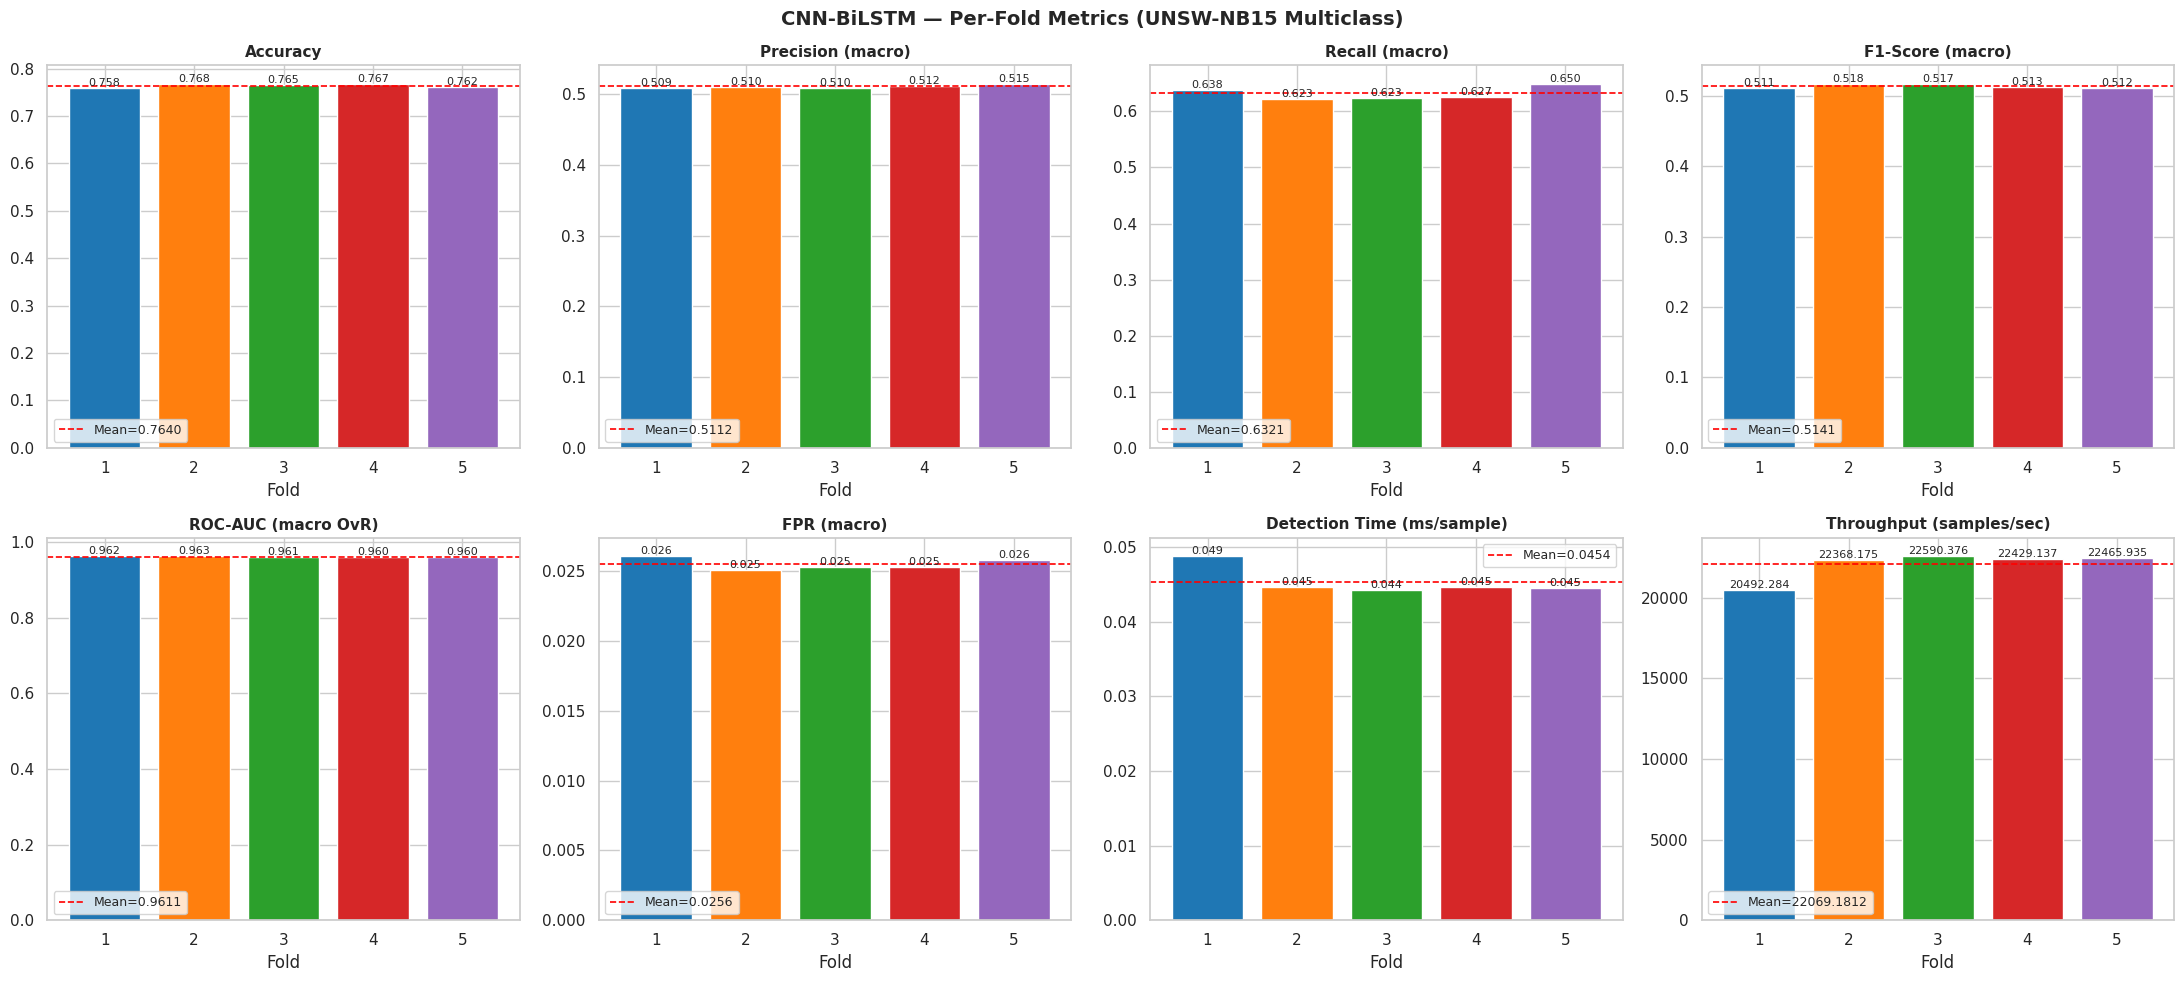

In [ ]:
metric_pairs = [
    ('acc',         'Accuracy'),
    ('precision',   'Precision (macro)'),
    ('recall',      'Recall (macro)'),
    ('f1',          'F1-Score (macro)'),
    ('roc_auc',     'ROC-AUC (macro OvR)'),
    ('fpr',         'FPR (macro)'),
    ('det_time_ms', 'Detection Time (ms/sample)'),
    ('throughput',  'Throughput (samples/sec)'),
]

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()
folds = cv_df.index.tolist()

for ax, (col, title) in zip(axes, metric_pairs):
    vals = cv_df[col].values
    bars = ax.bar(folds, vals, color=plt.cm.tab10.colors[:N_FOLDS], edgecolor='white')
    ax.axhline(vals.mean(), color='red', linestyle='--', linewidth=1.2,
               label=f'Mean={vals.mean():.4f}')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Fold'); ax.set_xticks(folds)
    ax.legend(fontsize=9)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('CNN-BiLSTM — Per-Fold Metrics (UNSW-NB15 Multiclass)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('per_fold_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

## 18. ROC Curves (Per Class — One-vs-Rest)

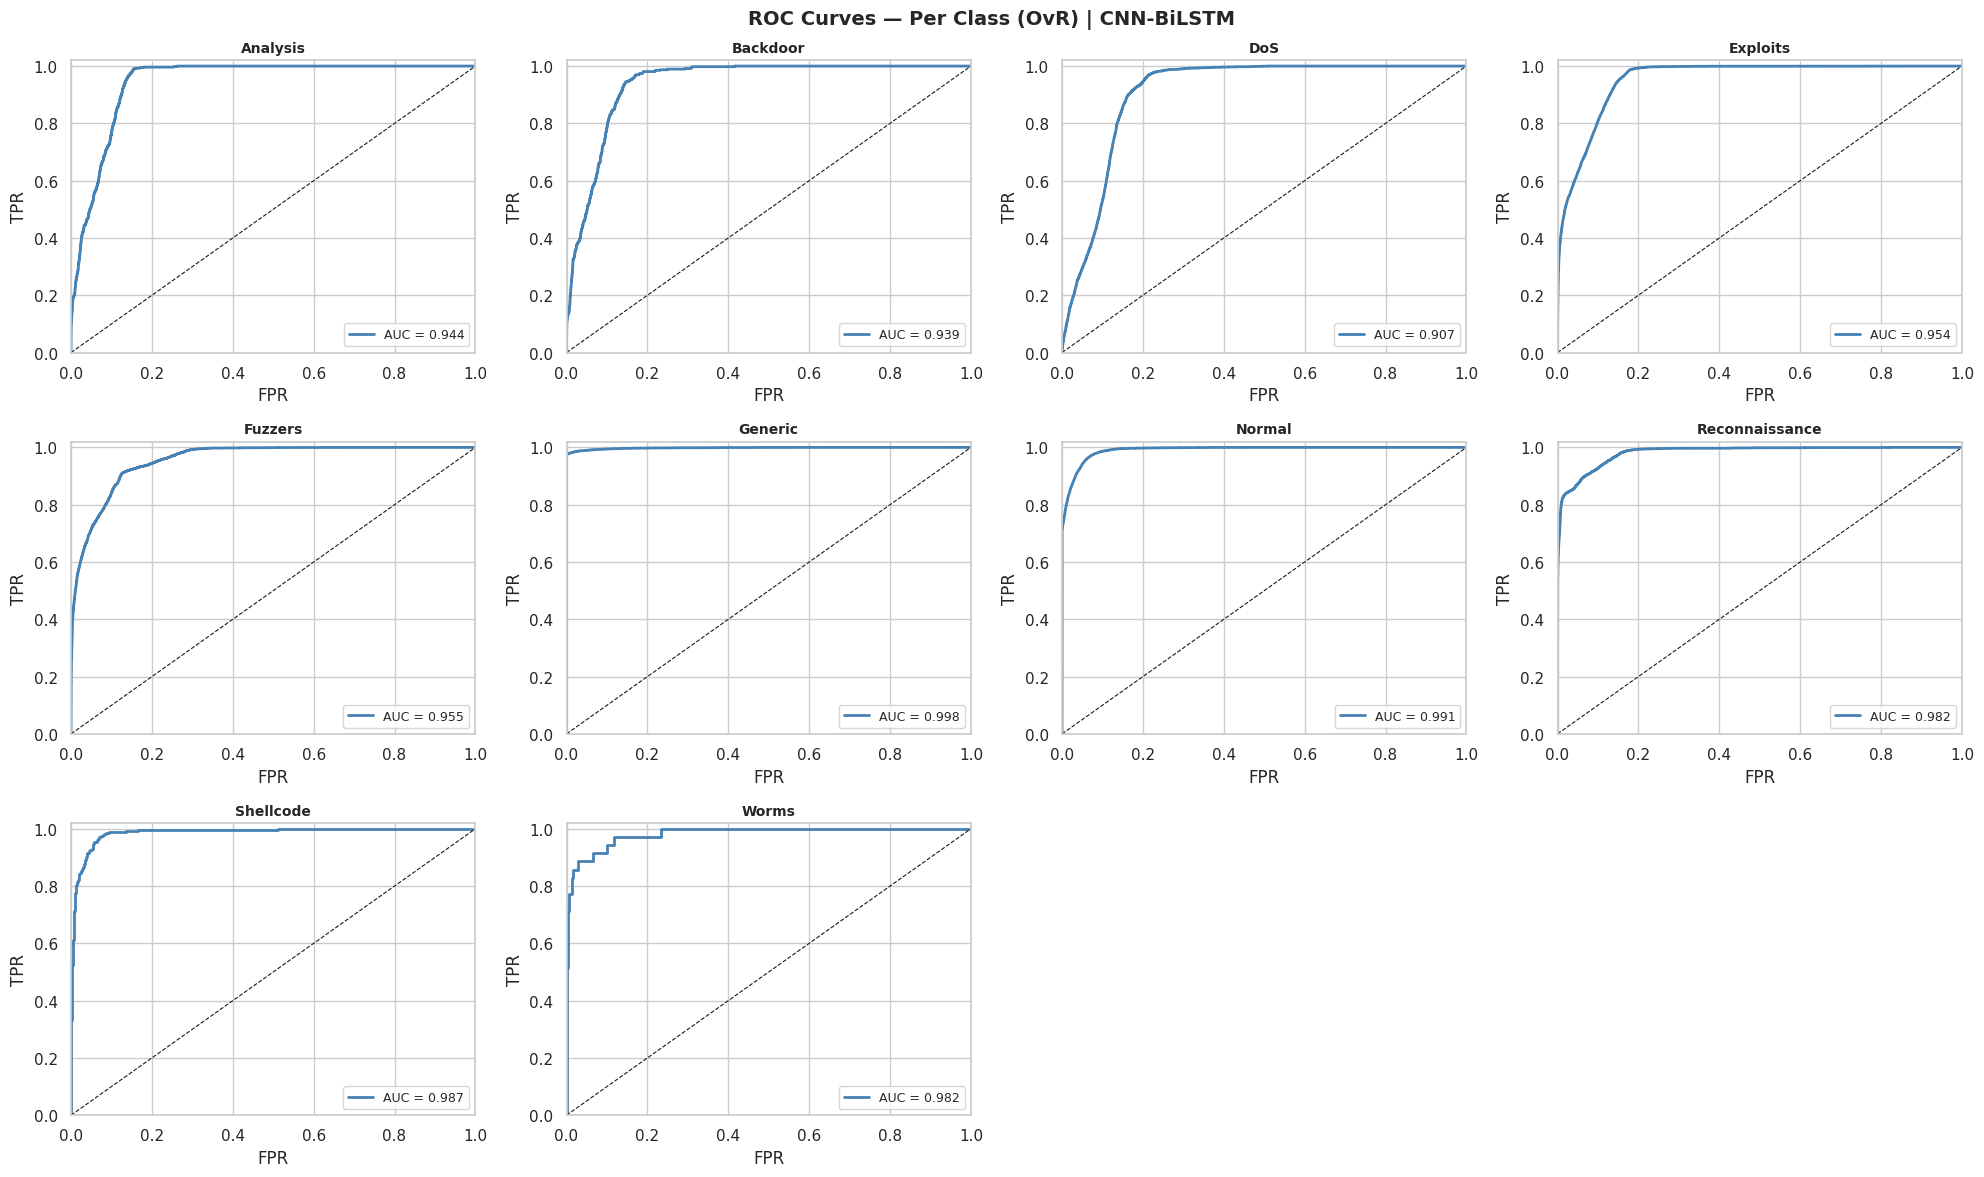

Per-class AUC:
  Analysis             AUC = 0.9438
  Backdoor             AUC = 0.9388
  DoS                  AUC = 0.9068
  Exploits             AUC = 0.9535
  Fuzzers              AUC = 0.9555
  Generic              AUC = 0.9982
  Normal               AUC = 0.9906
  Reconnaissance       AUC = 0.9816
  Shellcode            AUC = 0.9868
  Worms                AUC = 0.9819


In [ ]:
from sklearn.preprocessing import label_binarize

y_bin = label_binarize(y_true, classes=list(range(N_CLASSES)))
n_cols = 4
n_rows = int(np.ceil(N_CLASSES / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
axes = axes.flatten()

per_class_auc = []
for c in range(N_CLASSES):
    if y_bin[:, c].sum() == 0:
        per_class_auc.append(float('nan'))
        axes[c].set_visible(False)
        continue
    fpr_c, tpr_c, _ = roc_curve(y_bin[:, c], y_probs[:, c])
    auc_c = auc(fpr_c, tpr_c)
    per_class_auc.append(auc_c)
    axes[c].plot(fpr_c, tpr_c, lw=2, color='steelblue',
                 label=f'AUC = {auc_c:.3f}')
    axes[c].plot([0, 1], [0, 1], 'k--', lw=0.8)
    axes[c].set_title(CLASS_NAMES[c], fontsize=10, fontweight='bold')
    axes[c].set_xlabel('FPR'); axes[c].set_ylabel('TPR')
    axes[c].legend(fontsize=9)
    axes[c].set_xlim([0, 1]); axes[c].set_ylim([0, 1.02])

for ax in axes[N_CLASSES:]:
    ax.set_visible(False)

plt.suptitle('ROC Curves — Per Class (OvR) | CNN-BiLSTM',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print('Per-class AUC:')
for c, a in enumerate(per_class_auc):
    print(f'  {CLASS_NAMES[c]:<20} AUC = {a:.4f}')

## 19. Precision-Recall Curves (Per Class)

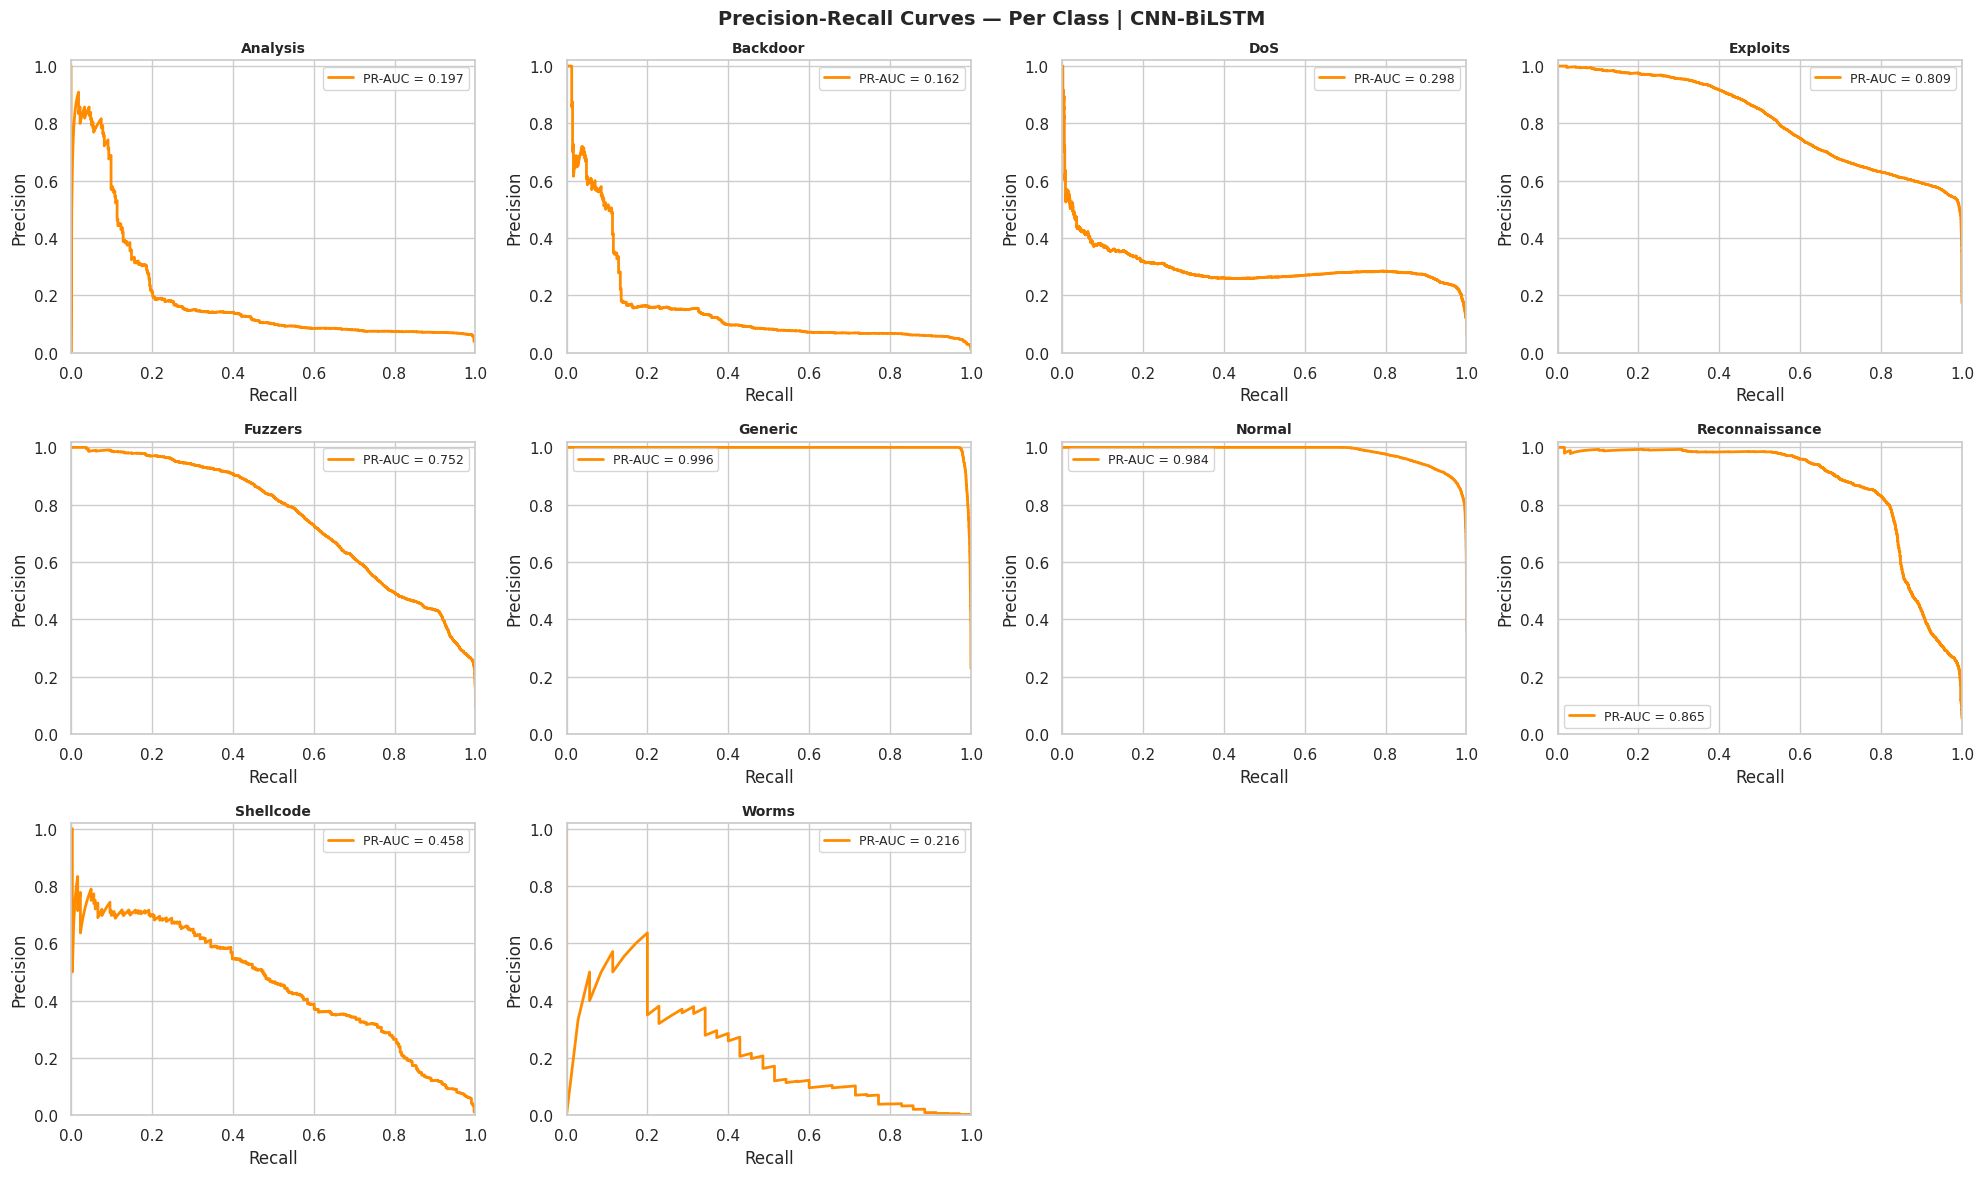

In [ ]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
axes = axes.flatten()

for c in range(N_CLASSES):
    if y_bin[:, c].sum() == 0:
        axes[c].set_visible(False)
        continue
    prec_c, rec_c, _ = precision_recall_curve(y_bin[:, c], y_probs[:, c])
    pr_auc = auc(rec_c, prec_c)
    axes[c].plot(rec_c, prec_c, lw=2, color='darkorange',
                 label=f'PR-AUC = {pr_auc:.3f}')
    axes[c].set_title(CLASS_NAMES[c], fontsize=10, fontweight='bold')
    axes[c].set_xlabel('Recall'); axes[c].set_ylabel('Precision')
    axes[c].legend(fontsize=9)
    axes[c].set_xlim([0, 1]); axes[c].set_ylim([0, 1.02])

for ax in axes[N_CLASSES:]:
    ax.set_visible(False)

plt.suptitle('Precision-Recall Curves — Per Class | CNN-BiLSTM',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 20. Individual Metric Summary Plots

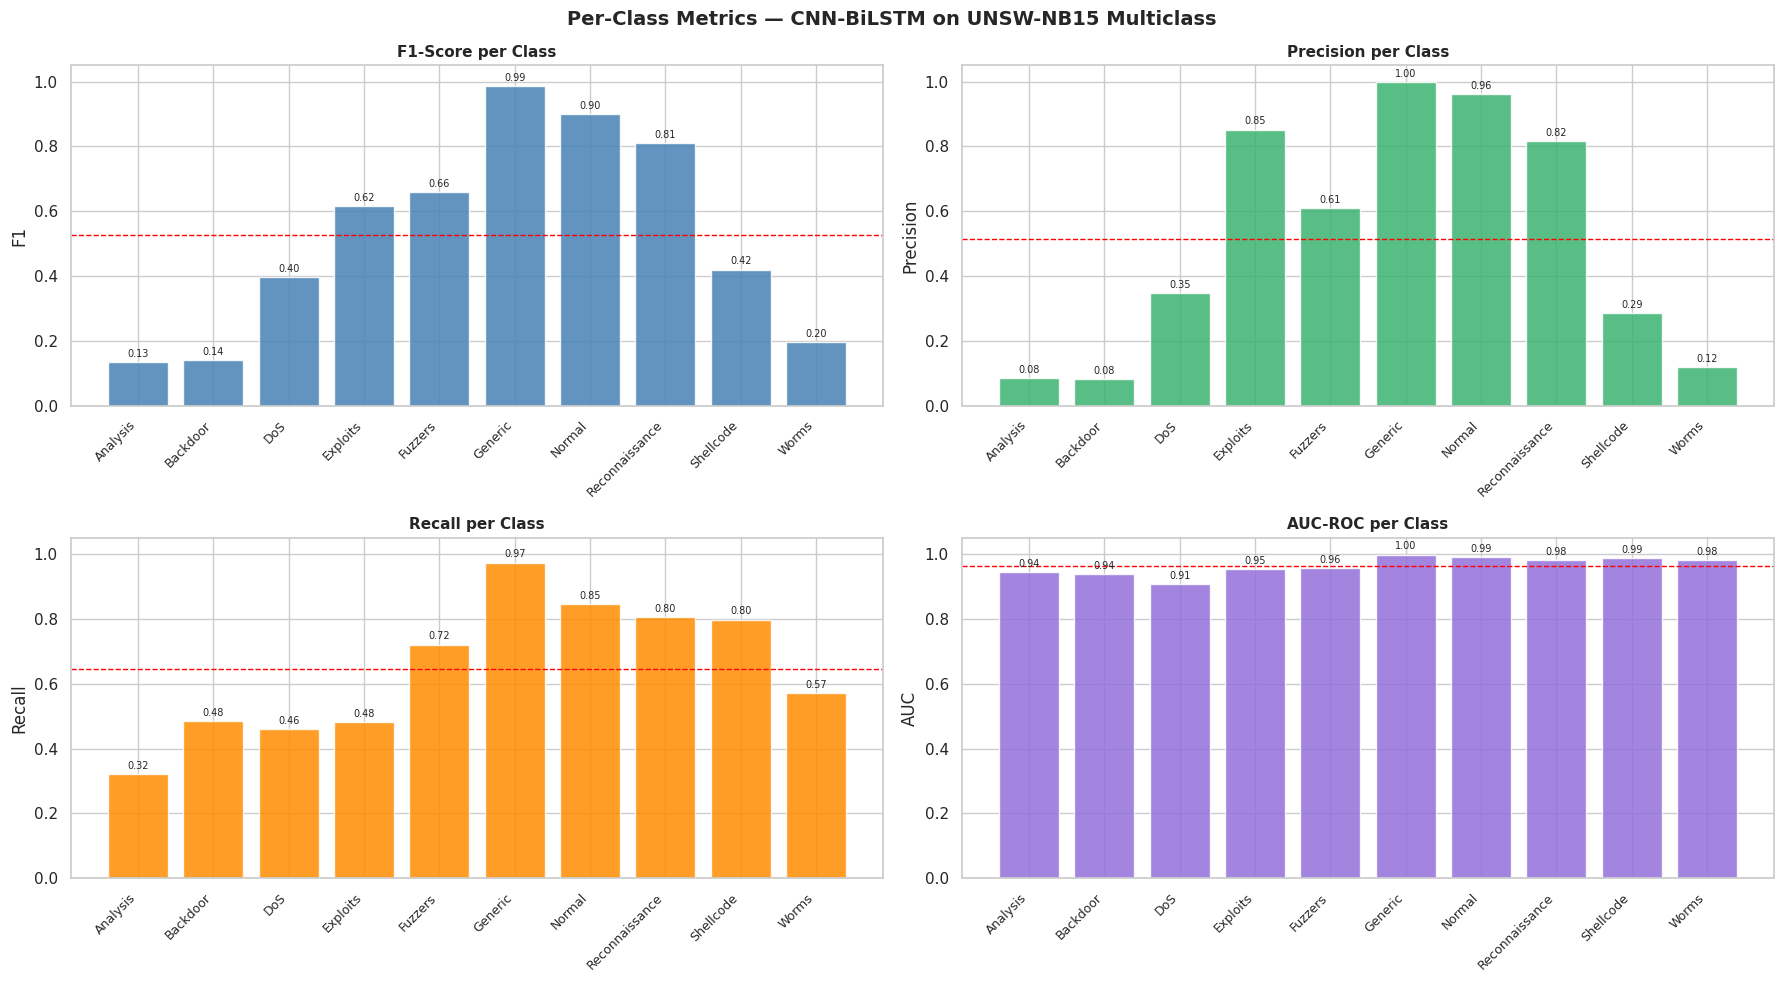

In [ ]:
# Per-class bar charts (F1, Precision, Recall, AUC)
report = classification_report(
    y_true, y_pred,
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0
)

classes     = CLASS_NAMES
f1_per      = [report[c]['f1-score']  for c in classes]
prec_per    = [report[c]['precision'] for c in classes]
rec_per     = [report[c]['recall']    for c in classes]
auc_per_cls = per_class_auc

def bar_chart(ax, values, title, ylabel, color):
    bars = ax.bar(range(len(classes)), values, color=color, edgecolor='white', alpha=0.85)
    ax.set_xticks(range(len(classes)))
    ax.set_xticklabels(classes, rotation=45, ha='right', fontsize=9)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, 1.05)
    ax.axhline(np.nanmean(values), color='red', linestyle='--', linewidth=1)
    for bar, v in zip(bars, values):
        if not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{v:.2f}', ha='center', va='bottom', fontsize=7)

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
bar_chart(axes[0,0], f1_per,      'F1-Score per Class',    'F1',        'steelblue')
bar_chart(axes[0,1], prec_per,    'Precision per Class',   'Precision', 'mediumseagreen')
bar_chart(axes[1,0], rec_per,     'Recall per Class',      'Recall',    'darkorange')
bar_chart(axes[1,1], auc_per_cls, 'AUC-ROC per Class',     'AUC',       'mediumpurple')

plt.suptitle('Per-Class Metrics — CNN-BiLSTM on UNSW-NB15 Multiclass',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('per_class_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

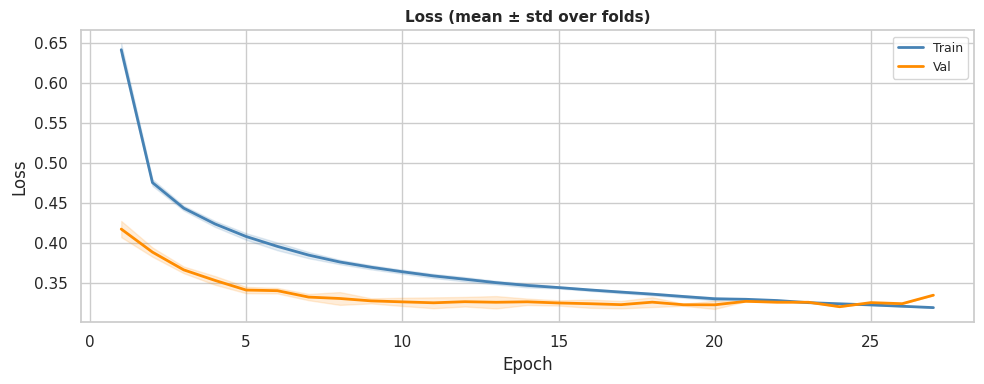

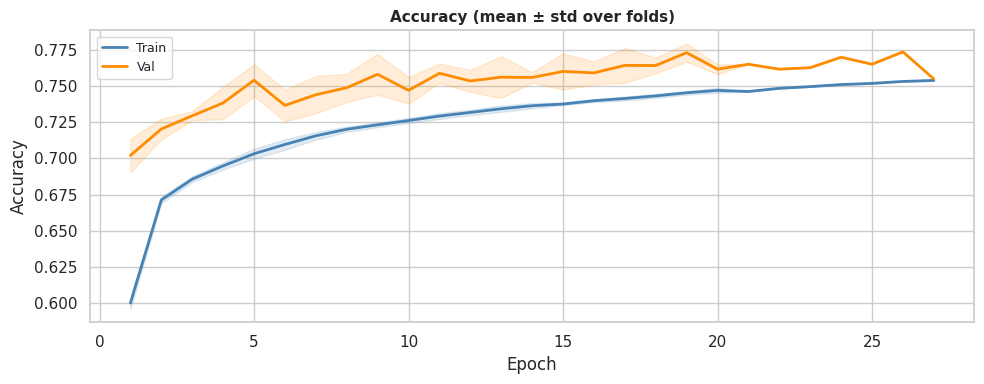

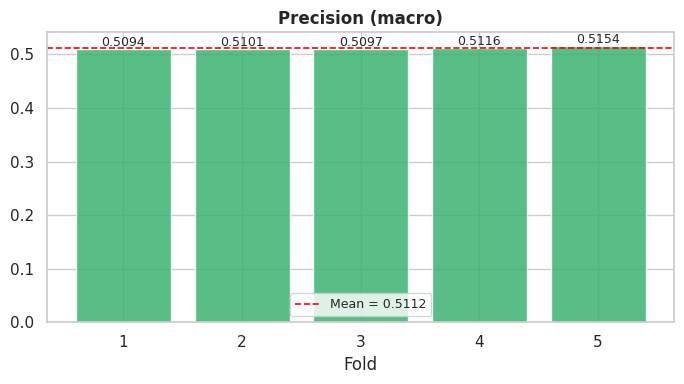

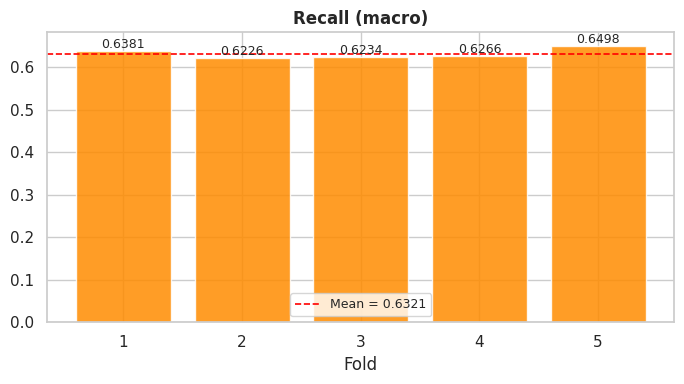

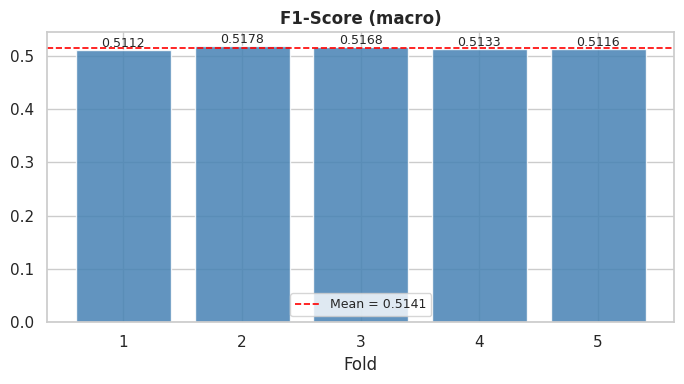

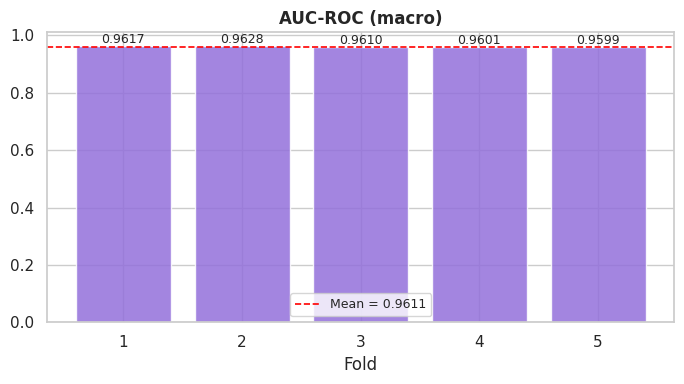

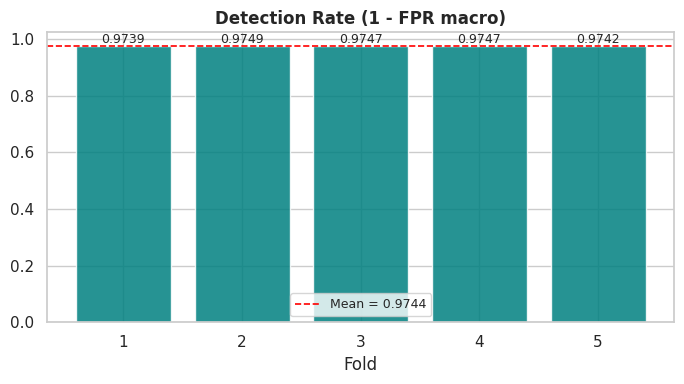

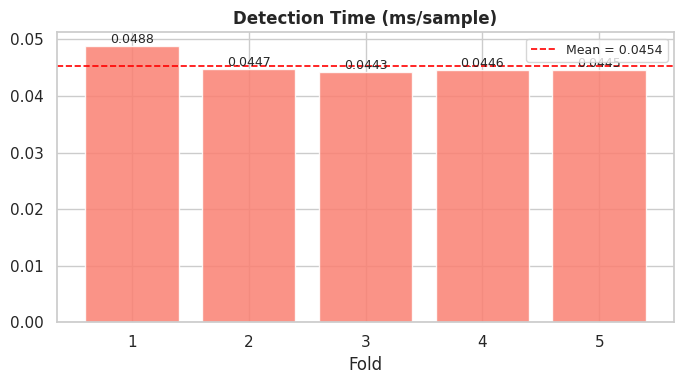

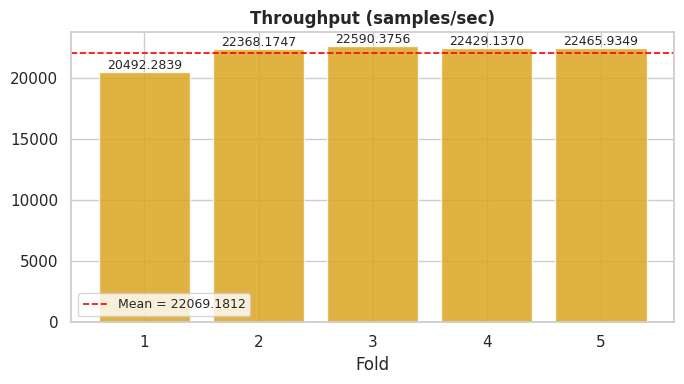

 All individual plots saved.


In [ ]:
# Individual metric plots (Loss, Acc, Prec, Rec, F1, AUC, Det.Rate,
#    Det.Time, Throughput) — averaged over folds

max_epochs = max(len(h['train_loss']) for h in cv_histories)

def pad_histories(key):
    """Pad shorter fold histories with NaN so we can average."""
    arrays = []
    for h in cv_histories:
        arr = np.array(h[key])
        if len(arr) < max_epochs:
            arr = np.concatenate([arr, np.full(max_epochs - len(arr), np.nan)])
        arrays.append(arr)
    return np.array(arrays)

tr_loss_mat = pad_histories('train_loss')
vl_loss_mat = pad_histories('val_loss')
tr_acc_mat  = pad_histories('train_acc')
vl_acc_mat  = pad_histories('val_acc')

epochs_x = np.arange(1, max_epochs + 1)

def plot_curve(ax, train_mat, val_mat, title, ylabel, color_tr='steelblue', color_vl='darkorange'):
    m_tr = np.nanmean(train_mat, axis=0)
    s_tr = np.nanstd(train_mat, axis=0)
    m_vl = np.nanmean(val_mat,   axis=0)
    s_vl = np.nanstd(val_mat,    axis=0)
    ax.plot(epochs_x, m_tr, color=color_tr, label='Train', lw=2)
    ax.fill_between(epochs_x, m_tr-s_tr, m_tr+s_tr, alpha=0.15, color=color_tr)
    ax.plot(epochs_x, m_vl, color=color_vl, label='Val', lw=2)
    ax.fill_between(epochs_x, m_vl-s_vl, m_vl+s_vl, alpha=0.15, color=color_vl)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.legend(fontsize=9)

# 1. Loss
fig, ax = plt.subplots(figsize=(10, 4))
plot_curve(ax, tr_loss_mat, vl_loss_mat, 'Loss (mean ± std over folds)', 'Loss')
plt.tight_layout(); plt.savefig('plot_loss.png', dpi=150, bbox_inches='tight'); plt.show()

# 2. Accuracy
fig, ax = plt.subplots(figsize=(10, 4))
plot_curve(ax, tr_acc_mat, vl_acc_mat, 'Accuracy (mean ± std over folds)', 'Accuracy')
plt.tight_layout(); plt.savefig('plot_accuracy.png', dpi=150, bbox_inches='tight'); plt.show()

# 3–9. CV scalar metrics — one bar plot per metric
scalar_plots = [
    ('precision',   'Precision (macro)', 'mediumseagreen'),
    ('recall',      'Recall (macro)',    'darkorange'),
    ('f1',          'F1-Score (macro)',  'steelblue'),
    ('roc_auc',     'AUC-ROC (macro)',   'mediumpurple'),
    ('fpr',         'Detection Rate (1 - FPR macro)', 'teal'),
    ('det_time_ms', 'Detection Time (ms/sample)',     'salmon'),
    ('throughput',  'Throughput (samples/sec)',        'goldenrod'),
]

for col, title, color in scalar_plots:
    vals = cv_df[col].values
    fname = f'plot_{col}.png'
    fig, ax = plt.subplots(figsize=(7, 4))

    if col == 'fpr':
        # Show Detection Rate = 1 - FPR
        vals = 1 - vals

    bars = ax.bar(range(1, N_FOLDS + 1), vals, color=color, edgecolor='white', alpha=0.85)
    ax.axhline(vals.mean(), color='red', linestyle='--', linewidth=1.2,
               label=f'Mean = {vals.mean():.4f}')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Fold'); ax.set_xticks(range(1, N_FOLDS + 1))
    ax.legend(fontsize=9)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{v:.4f}', ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()

print(' All individual plots saved.')

## 21. Save Best Model

In [ ]:
save_path = 'cnn_bilstm_unsw_nb15_best.pt'
torch.save({
    'model_state_dict' : best_model.state_dict(),
    'n_features'       : N_FEATURES,
    'n_classes'        : N_CLASSES,
    'class_names'      : CLASS_NAMES,
    'cnn_channels'     : CNN_OUT_CHANNELS,
    'lstm_hidden'      : LSTM_HIDDEN,
    'lstm_layers'      : LSTM_LAYERS,
    'fc_hidden'        : FC_HIDDEN,
    'best_fold'        : best_fold_idx + 1,
    'cv_results'       : cv_df.to_dict(),
    'test_metrics'     : {
        'acc': acc, 'precision': prec, 'recall': rec,
        'f1': f1, 'fpr': fpr_macro, 'roc_auc': roc_auc,
        'det_time_ms': det_time_ms, 'throughput': throughput
    }
}, save_path)
print(f' Model saved to {save_path}')

# How to reload:
# checkpoint = torch.load(save_path, map_location=DEVICE)
# model = build_model()
# model.load_state_dict(checkpoint['model_state_dict'])
# model.eval()

 Model saved to cnn_bilstm_unsw_nb15_best.pt
